# GHZ Circuit → Lattice Surgery Pipeline

End-to-end: load a GHZ circuit, decompose to Clifford+T, optimize via ZX calculus,
compile to surface code lattice surgery, and simulate.

In [1]:
# Imports
import sys, io, random
# import cudaq
import stim
import numpy as np
import pyzx as zx
import pymatching
from pyzx.simplify import to_rg
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
# from qiskit.transpiler.passes import OptimizeCliffordT
# from qiskit.primitives import StatevectorSampler
# from qiskit.qasm2 import dumps
# from qbraid import transpile as qbraid_transpile
# from topologiq.utils.interop_pyzx import pyzx_g_to_simple_g
# from topologiq.scripts.runner import run_topologiq_standard_hyperparams
from tqec import compile_block_graph
from tqec.computation.block_graph import BlockGraph
from tqec.utils.position import Position3D
from tqec.utils.noise_model import NoiseModel

# cudaq.set_target("qpp-cpu")

In [ ]:
from tqec import BlockGraph
from tqec.utils.position import Position3D
from tqec import compile_block_graph

g = BlockGraph("CNOT")
cubes = [
    (Position3D(0, 0, 0), "P", "In_Control"),
    (Position3D(0, 0, 1), "ZXX", ""),
    (Position3D(0, 0, 2), "ZXZ", ""),
    (Position3D(0, 0, 3), "P", "Out_Control"),
    (Position3D(0, 1, 1), "ZXX", ""),
    (Position3D(0, 1, 2), "ZXZ", ""),
    (Position3D(1, 1, 0), "P", "In_Target"),
    (Position3D(1, 1, 1), "ZXZ", ""),
    (Position3D(1, 1, 2), "ZXZ", ""),
    (Position3D(1, 1, 3), "P", "Out_Target"),
]
for pos, kind, label in cubes:
    g.add_cube(pos, kind, label)

pipes = [(0, 1), (1, 2), (2, 3), (1, 4), (4, 5), (5, 8), (6, 7), (7, 8), (8, 9)]

for p0, p1 in pipes:
    g.add_pipe(cubes[p0][0], cubes[p1][0])

# g.view_as_html()

filled = g.fill_ports_for_minimal_simulation()
fg = filled[0]
compiled = compile_block_graph(fg.graph)

print("=== GHZ-3 Lattice Surgery Compilation (with to_rg optimization) ===")
for k in [1]: # , 2, 3
    circ = compiled.generate_stim_circuit(k=k)
    d = 2 * k + 1
    print(circ)

=== GHZ-3 Lattice Surgery Compilation (with to_rg optimization) ===
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(0, 2) 1
QUBIT_COORDS(0, 4) 2
QUBIT_COORDS(0, 6) 3
QUBIT_COORDS(0, 8) 4
QUBIT_COORDS(0, 10) 5
QUBIT_COORDS(0, 12) 6
QUBIT_COORDS(0, 14) 7
QUBIT_COORDS(1, 1) 8
QUBIT_COORDS(1, 3) 9
QUBIT_COORDS(1, 5) 10
QUBIT_COORDS(1, 7) 11
QUBIT_COORDS(1, 9) 12
QUBIT_COORDS(1, 11) 13
QUBIT_COORDS(1, 13) 14
QUBIT_COORDS(2, 0) 15
QUBIT_COORDS(2, 2) 16
QUBIT_COORDS(2, 4) 17
QUBIT_COORDS(2, 6) 18
QUBIT_COORDS(2, 8) 19
QUBIT_COORDS(2, 10) 20
QUBIT_COORDS(2, 12) 21
QUBIT_COORDS(2, 14) 22
QUBIT_COORDS(3, 1) 23
QUBIT_COORDS(3, 3) 24
QUBIT_COORDS(3, 5) 25
QUBIT_COORDS(3, 7) 26
QUBIT_COORDS(3, 9) 27
QUBIT_COORDS(3, 11) 28
QUBIT_COORDS(3, 13) 29
QUBIT_COORDS(4, 0) 30
QUBIT_COORDS(4, 2) 31
QUBIT_COORDS(4, 4) 32
QUBIT_COORDS(4, 6) 33
QUBIT_COORDS(4, 8) 34
QUBIT_COORDS(4, 10) 35
QUBIT_COORDS(4, 12) 36
QUBIT_COORDS(4, 14) 37
QUBIT_COORDS(5, 1) 38
QUBIT_COORDS(5, 3) 39
QUBIT_COORDS(5, 5) 40
QUBIT_COORDS(5, 7) 41
QUBIT

In [17]:
from tqec import BlockGraph
from tqec.utils.position import Position3D
from tqec import compile_block_graph

# IDLE 0 [(0,0)] D [] [] [] [] [] [] none False none
# INJECT_T 1 [(1,0)] D [] [] [] [] [] [] none True none
# MERGE 2 [(1,0),(0,0)] D [] [4,5,6,7] [] [] [((0,0),(1,0))] [] none True none
# DISCARD 3 [(1,0)] 0 [] [] [] [] [] [] none True none
# MERGE 4 [(1,0),(0,0)] D [2] [] [] [] [((0,0),(1,0))] [4,5,6,7] CONDITIONAL_S True none
# Y_MEAS 5 [(1,0)] HALF_D_PLUS_2 [2] [] [] [] [] [4,5,6,7] CONDITIONAL_S True none
# IDLE 6 [(0,0)] HALF_D_PLUS_2 [2] [] [] [] [] [4,5,6,7] CONDITIONAL_S True none
# DISCARD 7 [(1,0)] 0 [2] [] [] [] [] [4,5,6,7] CONDITIONAL_S True none

# TODO: Figure out how P vs ZXZ differs in measurements/reset basis
#TODO: try another one with in port instead of out port
g = BlockGraph()
# second merge WITH port TODO
# cubes = [
#     # IDLE (0,0) D
#     (Position3D(0, 0, 0), "ZXZ", ""),

#     # INJECT_T (1,0) D
#     (Position3D(1, 0, 1), "ZXZ", "S"),
#     (Position3D(0, 0, 1), "ZXZ", ""),

#     # MERGE (1,0) (0,0) D
#     # Add a pipe between (1,0) and (0,0) here
#     (Position3D(1, 0, 2), "ZXZ", "S"), # might not need this S indicator, because it should alr be in S state here
#     (Position3D(0, 0, 2), "ZXZ", ""),

#     # DISCARD (1,0) 0
#     # Need to adjust this to take 0 rounds/discard right after instead of having a bunch of rounds for it bc this will still take d rounds of measurement here
#     # (Position3D(1, 0, 3), "P", "Out_Control_S"),
#     (Position3D(0, 0, 3), "ZXZ", ""), # since we discard (1,0), we do nothing with (1,0) this round

#     # MERGE (1,0) (0,0) D
#     (Position3D(1, 0, 4), "P", "In_Control_S"),
#     (Position3D(1, 0, 5), "ZXZ", "In_Control_S"),

    
#     (Position3D(0, 0, 4), "P", "Out_Control"),
#     # (Position3D(1, 0, 2), "P", "Out_Control_S"),
#     # (Position3D(1, 0, 1), "ZXZ", ""),
#     # (Position3D(1, 0, 2), "P", "Out_Control_S"),
# ]

# second merge without port!!!!!
cubes = [
    # IDLE (0,0) D
    (Position3D(0, 0, 0), "ZXZ", ""),
    # (Position3D(0, 0, 0), "P", "In_Control"),

    # INJECT_T (1,0) D
    (Position3D(1, 0, 1), "ZXZ", "S"),
    (Position3D(0, 0, 1), "ZXZ", ""),

    # MERGE (1,0) (0,0) D
    # Add a pipe between (1,0) and (0,0) here
    (Position3D(1, 0, 2), "ZXZ", "S"), # might not need this S indicator, because it should alr be in S state here
    (Position3D(0, 0, 2), "ZXZ", ""),

    # DISCARD (1,0) 0
    # Need to adjust this to take 0 rounds/discard right after instead of having a bunch of rounds for it bc this will still take d rounds of measurement here
    # (Position3D(1, 0, 3), "P", "Out_Control_S"),
    # TODO might be able to get rid of this
    # (Position3D(0, 0, 3), "ZXZ", ""), # since we discard (1,0), we do nothing with (1,0) this round

    # MERGE (1,0) (0,0) D
    (Position3D(1, 0, 3), "ZXZ", "In_Control_S"),
    (Position3D(0, 0, 3), "ZXZ", ""),

    # Y_MEAS (1,0) HALF_D_PLUS_2
    (Position3D(1, 0, 4), "ZXZ", "Y"), # STOP HERE # COULD/SHOULD THIS BE A PORT?
    # (Position3D(0, 0, 4), "ZXZ", ""),

    # IDLE (0,0) HALF_D_PLUS_2
    # (Position3D(0, 0, 6), "ZXZ", ""),
    (Position3D(0, 0, 4), "P", "Out_Control"),
    # (Position3D(0, 0, 5), "ZXZ", ""),

    # DISCARD (1,0) 0    
    # (Position3D(0, 0, 7), "P", "Out_Control"),
    # Nothing for (1,0) -- it's just done because it's discarded


    # (Position3D(1, 0, 2), "P", "Out_Control_S"),
    # (Position3D(1, 0, 1), "ZXZ", ""),
    # (Position3D(1, 0, 2), "P", "Out_Control_S"),
]

for pos, kind, label in cubes:
    g.add_cube(pos, kind, label)

# pipes = [(0, 1), (1, 2), (3,4), (4,5), (1,4)] # (1,4) should merge the 2 patches together!
# pipes = [(0, 2), (2,4), (4,6), (6,9), (3,4), (1, 3), (3, 5), (5, 7), (7, 8)]
# pipes = [(0, 2), (2,4), (4,5), (5,7), (7,9), (9, 10), (1, 3), (6, 8), (3, 4), (6, 7)] # , (10, 11)
# pipes = [(0, 2), (2,4), (4,6), (6,8), (8,9), (1, 3), (5, 7), (3, 4), (5, 6)] # , (10, 11)
pipes = [(0, 2), (2,4), (4,6), (6,8), (1, 3), (5, 7), (3, 4), (5, 6)] # , (10, 11)


for p0, p1 in pipes:
    g.add_pipe(cubes[p0][0], cubes[p1][0])



filled = g.fill_ports_for_minimal_simulation()
fg = filled[0]
compiled = compile_block_graph(fg.graph)

print("=== GHZ-3 Lattice Surgery Compilation (with to_rg optimization) ===")
for k in [1]: # , 2, 3
    circ = compiled.generate_stim_circuit(k=k)
    d = 2 * k + 1
    print(circ)

g.view_as_html("graph.html")

=== GHZ-3 Lattice Surgery Compilation (with to_rg optimization) ===
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(0, 2) 1
QUBIT_COORDS(0, 4) 2
QUBIT_COORDS(0, 6) 3
QUBIT_COORDS(1, 1) 4
QUBIT_COORDS(1, 3) 5
QUBIT_COORDS(1, 5) 6
QUBIT_COORDS(2, 0) 7
QUBIT_COORDS(2, 2) 8
QUBIT_COORDS(2, 4) 9
QUBIT_COORDS(2, 6) 10
QUBIT_COORDS(3, 1) 11
QUBIT_COORDS(3, 3) 12
QUBIT_COORDS(3, 5) 13
QUBIT_COORDS(4, 0) 14
QUBIT_COORDS(4, 2) 15
QUBIT_COORDS(4, 4) 16
QUBIT_COORDS(4, 6) 17
QUBIT_COORDS(5, 1) 18
QUBIT_COORDS(5, 3) 19
QUBIT_COORDS(5, 5) 20
QUBIT_COORDS(6, 0) 21
QUBIT_COORDS(6, 2) 22
QUBIT_COORDS(6, 4) 23
QUBIT_COORDS(6, 6) 24
QUBIT_COORDS(7, 1) 25
QUBIT_COORDS(7, 3) 26
QUBIT_COORDS(7, 5) 27
QUBIT_COORDS(8, 0) 28
QUBIT_COORDS(8, 2) 29
QUBIT_COORDS(8, 4) 30
QUBIT_COORDS(8, 6) 31
QUBIT_COORDS(9, 1) 32
QUBIT_COORDS(9, 3) 33
QUBIT_COORDS(9, 5) 34
QUBIT_COORDS(10, 0) 35
QUBIT_COORDS(10, 2) 36
QUBIT_COORDS(10, 4) 37
QUBIT_COORDS(10, 6) 38
QUBIT_COORDS(11, 1) 39
QUBIT_COORDS(11, 3) 40
QUBIT_COORDS(11, 5) 41
QUBIT_COORD

In [1]:
from tqec import BlockGraph
from tqec.utils.position import Position3D
from tqec import compile_block_graph

# IDLE 0 [(0,0)] D [] [] [] [] [] [] none False none
# INJECT_T 1 [(1,0)] D [] [] [] [] [] [] none True none
# MERGE 2 [(1,0),(0,0)] D [] [4,5,6,7] [] [] [((0,0),(1,0))] [] none True none
# DISCARD 3 [(1,0)] 0 [] [] [] [] [] [] none True none
# MERGE 4 [(1,0),(0,0)] D [2] [] [] [] [((0,0),(1,0))] [4,5,6,7] CONDITIONAL_S True none
# Y_MEAS 5 [(1,0)] HALF_D_PLUS_2 [2] [] [] [] [] [4,5,6,7] CONDITIONAL_S True none
# IDLE 6 [(0,0)] HALF_D_PLUS_2 [2] [] [] [] [] [4,5,6,7] CONDITIONAL_S True none
# DISCARD 7 [(1,0)] 0 [2] [] [] [] [] [4,5,6,7] CONDITIONAL_S True none

# TODO: Figure out how P vs ZXZ differs in measurements/reset basis
#TODO: try another one with in port instead of out port
g = BlockGraph()
# second merge WITH port TODO
# cubes = [
#     # IDLE (0,0) D
#     (Position3D(0, 0, 0), "ZXZ", ""),

#     # INJECT_T (1,0) D
#     (Position3D(1, 0, 1), "ZXZ", "S"),
#     (Position3D(0, 0, 1), "ZXZ", ""),

#     # MERGE (1,0) (0,0) D
#     # Add a pipe between (1,0) and (0,0) here
#     (Position3D(1, 0, 2), "ZXZ", "S"), # might not need this S indicator, because it should alr be in S state here
#     (Position3D(0, 0, 2), "ZXZ", ""),

#     # DISCARD (1,0) 0
#     # Need to adjust this to take 0 rounds/discard right after instead of having a bunch of rounds for it bc this will still take d rounds of measurement here
#     # (Position3D(1, 0, 3), "P", "Out_Control_S"),
#     (Position3D(0, 0, 3), "ZXZ", ""), # since we discard (1,0), we do nothing with (1,0) this round

#     # MERGE (1,0) (0,0) D
#     (Position3D(1, 0, 4), "P", "In_Control_S"),
#     (Position3D(1, 0, 5), "ZXZ", "In_Control_S"),

    
#     (Position3D(0, 0, 4), "P", "Out_Control"),
#     # (Position3D(1, 0, 2), "P", "Out_Control_S"),
#     # (Position3D(1, 0, 1), "ZXZ", ""),
#     # (Position3D(1, 0, 2), "P", "Out_Control_S"),
# ]

# second merge without port!!!!!
cubes = [
    (Position3D(x=0, y=0, z=0), 'P', 'In_Idle_0_0'),
    (Position3D(x=1, y=0, z=1), 'ZXZ', 'S_1_0_0'),
    (Position3D(x=0, y=0, z=1), 'ZXZ', ''),
    (Position3D(x=0, y=0, z=2), 'ZXZ', ''),
    (Position3D(x=1, y=0, z=2), 'ZXZ', ''),
    (Position3D(x=0, y=0, z=3), 'ZXZ', ''),
    (Position3D(x=1, y=0, z=3), 'ZXZ', ''),
    (Position3D(x=1, y=0, z=4), 'ZXZ', ''),
    (Position3D(x=0, y=0, z=4), 'ZXZ', '')
]

for pos, kind, label in cubes:
    g.add_cube(pos, kind, label)

pipes = [(0, 2), (2,3), (3,5), (3,4), (5, 6), (1, 4), (6, 7), (5,8)] # , (10, 11)


for p0, p1 in pipes:
    g.add_pipe(cubes[p0][0], cubes[p1][0])



filled = g.fill_ports_for_minimal_simulation()
fg = filled[0]
compiled = compile_block_graph(fg.graph)

print("=== GHZ-3 Lattice Surgery Compilation (with to_rg optimization) ===")
for k in [1]: # , 2, 3
    circ = compiled.generate_stim_circuit(k=k)
    d = 2 * k + 1
    print(circ)

g.view_as_html("graph.html")

=== GHZ-3 Lattice Surgery Compilation (with to_rg optimization) ===
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(0, 2) 1
QUBIT_COORDS(0, 4) 2
QUBIT_COORDS(0, 6) 3
QUBIT_COORDS(1, 1) 4
QUBIT_COORDS(1, 3) 5
QUBIT_COORDS(1, 5) 6
QUBIT_COORDS(2, 0) 7
QUBIT_COORDS(2, 2) 8
QUBIT_COORDS(2, 4) 9
QUBIT_COORDS(2, 6) 10
QUBIT_COORDS(3, 1) 11
QUBIT_COORDS(3, 3) 12
QUBIT_COORDS(3, 5) 13
QUBIT_COORDS(4, 0) 14
QUBIT_COORDS(4, 2) 15
QUBIT_COORDS(4, 4) 16
QUBIT_COORDS(4, 6) 17
QUBIT_COORDS(5, 1) 18
QUBIT_COORDS(5, 3) 19
QUBIT_COORDS(5, 5) 20
QUBIT_COORDS(6, 0) 21
QUBIT_COORDS(6, 2) 22
QUBIT_COORDS(6, 4) 23
QUBIT_COORDS(6, 6) 24
QUBIT_COORDS(7, 1) 25
QUBIT_COORDS(7, 3) 26
QUBIT_COORDS(7, 5) 27
QUBIT_COORDS(8, 0) 28
QUBIT_COORDS(8, 2) 29
QUBIT_COORDS(8, 4) 30
QUBIT_COORDS(8, 6) 31
QUBIT_COORDS(9, 1) 32
QUBIT_COORDS(9, 3) 33
QUBIT_COORDS(9, 5) 34
QUBIT_COORDS(10, 0) 35
QUBIT_COORDS(10, 2) 36
QUBIT_COORDS(10, 4) 37
QUBIT_COORDS(10, 6) 38
QUBIT_COORDS(11, 1) 39
QUBIT_COORDS(11, 3) 40
QUBIT_COORDS(11, 5) 41
QUBIT_COORD

In [ ]:
from tqec import BlockGraph
from tqec.utils.position import Position3D
from tqec import compile_block_graph

g = BlockGraph("CNOT")
cubes = [
    (Position3D(0, 0, 0), "P", "In_Control"),
    (Position3D(0, 0, 1), "ZXZ", ""),
    (Position3D(0, 0, 2), "P", "Out_Control"),
    (Position3D(1, 0, 0), "P", "In_Control_S"),
    (Position3D(1, 0, 1), "ZXZ", ""),
    (Position3D(1, 0, 2), "P", "Out_Control_S"),
]

# cubes = [
#     # IDLE (0,0) D
#     (Position3D(0, 0, 0), "P", "Open_Port"),
#     (Position3D(0, 0, 1), "ZXZ", ""),
#     (Position3D(0, 0, 2), "P", "Open_Port_2"),
#     (Position3D(0, 0, 3), "ZXZ", ""),
# ]

for pos, kind, label in cubes:
    g.add_cube(pos, kind, label)

pipes = [(0, 1), (1, 2), (3,4), (4,5), (1,4)] # (1,4) should merge the 2 patches together!
# pipes = [(0, 1), (2,3)]

for p0, p1 in pipes:
    g.add_pipe(cubes[p0][0], cubes[p1][0])



filled = g.fill_ports_for_minimal_simulation()
fg = filled[0]
compiled = compile_block_graph(fg.graph)

print("=== GHZ-3 Lattice Surgery Compilation (with to_rg optimization) ===")
for k in [1]: # , 2, 3
    circ = compiled.generate_stim_circuit(k=k)
    d = 2 * k + 1
    print(circ)

g.view_as_html("graph.html")

=== GHZ-3 Lattice Surgery Compilation (with to_rg optimization) ===
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(0, 2) 1
QUBIT_COORDS(0, 4) 2
QUBIT_COORDS(0, 6) 3
QUBIT_COORDS(1, 1) 4
QUBIT_COORDS(1, 3) 5
QUBIT_COORDS(1, 5) 6
QUBIT_COORDS(2, 0) 7
QUBIT_COORDS(2, 2) 8
QUBIT_COORDS(2, 4) 9
QUBIT_COORDS(2, 6) 10
QUBIT_COORDS(3, 1) 11
QUBIT_COORDS(3, 3) 12
QUBIT_COORDS(3, 5) 13
QUBIT_COORDS(4, 0) 14
QUBIT_COORDS(4, 2) 15
QUBIT_COORDS(4, 4) 16
QUBIT_COORDS(4, 6) 17
QUBIT_COORDS(5, 1) 18
QUBIT_COORDS(5, 3) 19
QUBIT_COORDS(5, 5) 20
QUBIT_COORDS(6, 0) 21
QUBIT_COORDS(6, 2) 22
QUBIT_COORDS(6, 4) 23
QUBIT_COORDS(6, 6) 24
QUBIT_COORDS(7, 1) 25
QUBIT_COORDS(7, 3) 26
QUBIT_COORDS(7, 5) 27
QUBIT_COORDS(8, 0) 28
QUBIT_COORDS(8, 2) 29
QUBIT_COORDS(8, 4) 30
QUBIT_COORDS(8, 6) 31
QUBIT_COORDS(9, 1) 32
QUBIT_COORDS(9, 3) 33
QUBIT_COORDS(9, 5) 34
QUBIT_COORDS(10, 0) 35
QUBIT_COORDS(10, 2) 36
QUBIT_COORDS(10, 4) 37
QUBIT_COORDS(10, 6) 38
QUBIT_COORDS(11, 1) 39
QUBIT_COORDS(11, 3) 40
QUBIT_COORDS(11, 5) 41
QUBIT_COORD

In [19]:
from tqec import BlockGraph
from tqec.utils.position import Position3D
from tqec import compile_block_graph

g = BlockGraph("CNOT")
# cubes = [
#     (Position3D(0, 0, 0), "ZXZ", ""),
#     (Position3D(0, 0, 1), "P", "Out_Control"),
#     (Position3D(0, 0, 2), "P", "In_Control"),
#     (Position3D(0, 0, 3), "ZXZ", ""),
#     (Position3D(0, 0, 4), "P", "Out_Control1"),
# ]
# cubes = [
#     (Position3D(0, 0, 0), "ZXZ", ""),
#     (Position3D(1, 0, 0), "ZXZ", "In_Control"),
#     (Position3D(0, 0, 1), "P", "Out_Control"),
#     (Position3D(1, 0, 1), "P", "Out_Control_1"),
# ]
cubes = [
    (Position3D(0, 0, 0), "P", "In_Control"),
    (Position3D(0, 0, 1), "ZXZ", ""),
]
for pos, kind, label in cubes:
    g.add_cube(pos, kind, label)

# pipes = [(0,1), (1,2), (2,3), (3,4)] # (1,4) should merge the 2 patches together! # (0, 1), (1, 2), (3,4), (4,5), (1,4)
# pipes = [(0,1), (0,2), (1,3)]
pipes = [(0,1)]

for p0, p1 in pipes:
    g.add_pipe(cubes[p0][0], cubes[p1][0])



filled = g.fill_ports_for_minimal_simulation()
fg = filled[0]
compiled = compile_block_graph(fg.graph)

print("=== GHZ-3 Lattice Surgery Compilation (with to_rg optimization) ===")
for k in [1]: # , 2, 3
    circ = compiled.generate_stim_circuit(k=k)
    d = 2 * k + 1
    print(circ)

g.view_as_html("graph.html")

=== GHZ-3 Lattice Surgery Compilation (with to_rg optimization) ===
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(0, 2) 1
QUBIT_COORDS(0, 4) 2
QUBIT_COORDS(0, 6) 3
QUBIT_COORDS(1, 1) 4
QUBIT_COORDS(1, 3) 5
QUBIT_COORDS(1, 5) 6
QUBIT_COORDS(2, 0) 7
QUBIT_COORDS(2, 2) 8
QUBIT_COORDS(2, 4) 9
QUBIT_COORDS(2, 6) 10
QUBIT_COORDS(3, 1) 11
QUBIT_COORDS(3, 3) 12
QUBIT_COORDS(3, 5) 13
QUBIT_COORDS(4, 0) 14
QUBIT_COORDS(4, 2) 15
QUBIT_COORDS(4, 4) 16
QUBIT_COORDS(4, 6) 17
QUBIT_COORDS(5, 1) 18
QUBIT_COORDS(5, 3) 19
QUBIT_COORDS(5, 5) 20
QUBIT_COORDS(6, 0) 21
QUBIT_COORDS(6, 2) 22
QUBIT_COORDS(6, 4) 23
QUBIT_COORDS(6, 6) 24
RX 2 7 8 9 15 16 17 22
R 4 5 6 11 12 13 18 19 20
TICK
CZ 8 4 16 12 22 18
CX 9 5 15 11 17 13
TICK
CX 9 12 15 18 17 20
CZ 2 5
TICK
CX 7 4 9 6 15 12
CZ 8 5 16 13 22 19
TICK
CZ 8 11 16 19
TICK
CX 7 11 9 13 15 19
CZ 2 6 8 12 16 20
TICK
MX 2 7 8 9 15 16 17 22
DETECTOR(4, 4, 0) rec[-3]
DETECTOR(0, 4, 0) rec[-8]
DETECTOR(2, 2, 0) rec[-6]
DETECTOR(6, 2, 0) rec[-1]
SHIFT_COORDS(0, 0, 1)
TICK
RX 2 7 

## 1. Load GHZ Circuit

In [2]:
# Load 3-qubit GHZ from QASM3 file via qbraid
with open("ghz_3q.qasm3") as f:
    qasm3_str = f.read()

# Build Qiskit circuit with explicit measure (no barrier — qbraid→cudaq chokes on barriers)
qc_raw = qbraid_transpile(qasm3_str, "qiskit")
n = qc_raw.num_qubits
qc = QuantumCircuit(n, n)
qc.compose(qc_raw, inplace=True)
qc.measure(list(range(n)), list(range(n)))

print(qc.draw())
print(f"Gates: {qc.count_ops()}")

               ┌───┐┌─┐   
q_0: ──────────┤ X ├┤M├───
          ┌───┐└─┬─┘└╥┘┌─┐
q_1: ─────┤ X ├──■───╫─┤M├
     ┌───┐└─┬─┘ ┌─┐  ║ └╥┘
q_2: ┤ H ├──■───┤M├──╫──╫─
     └───┘      └╥┘  ║  ║ 
c: 3/════════════╩═══╩══╩═
                 2   0  1 
Gates: OrderedDict({'measure': 3, 'cx': 2, 'h': 1})


## 2. Clifford+T Decomposition

Use Qiskit's gridsynth to decompose arbitrary rotations into the Clifford+T gate set,
then optimize T-count.

In [3]:
# Decompose to Clifford+T basis using gridsynth
pm = generate_preset_pass_manager(
    optimization_level=2,
    basis_gates=["h", "s", "t", "tdg", "sdg", "cx", "x", "y", "z"],
    unitary_synthesis_method="gridsynth",
    unitary_synthesis_plugin_config={"epsilon": 1e-4},
)
qc_ct = pm.run(qc)
qc_ct = OptimizeCliffordT()(qc_ct)

ops = qc_ct.count_ops()
t_count = ops.get("t", 0) + ops.get("tdg", 0)
print(f"Gates: {ops}")
print(f"T-count: {t_count}")
print(f"Note: GHZ is purely Clifford, so T-count should be 0")

Gates: OrderedDict({'measure': 3, 'cx': 2, 'h': 1})
T-count: 0
Note: GHZ is purely Clifford, so T-count should be 0


## 3. Simulate on CUDA-Q (CPU) and Qiskit

In [4]:
# CUDA-Q simulation (CPU backend)
kernel = qbraid_transpile(qc, "cudaq")
result = cudaq.sample(kernel, shots_count=1024)
print("CUDA-Q:")
print(result)
print(cudaq.draw(kernel))

# Qiskit StatevectorSampler
sampler = StatevectorSampler()
counts = sampler.run([qc_ct], shots=1024).result()[0].data.c.get_counts()
print("\nQiskit StatevectorSampler:")
for bs, c in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {bs}: {c}")

CUDA-Q:
{ 000:522 111:502 }

               ╭───╮
q0 : ──────────┤ x ├
          ╭───╮╰─┬─╯
q1 : ─────┤ x ├──●──
     ╭───╮╰─┬─╯     
q2 : ┤ h ├──●───────
     ╰───╯          


Qiskit StatevectorSampler:
  000: 513
  111: 511


## 4. PyZX: ZX-Calculus Optimization

ZX diagrams are the natural language of lattice surgery
([Quantum 2020](https://quantum-journal.org/papers/q-2020-01-09-218/)).
Convert to a ZX graph and optimize.

In [5]:
# Convert Clifford+T QASM to PyZX (strip measurements first)
qasm_ct = dumps(qc_ct)
qasm_clean = "\n".join(
    l for l in qasm_ct.split("\n")
    if not l.strip().startswith(("measure", "creg"))
)

c_pyzx = zx.Circuit.from_qasm(qasm_clean)
print(f"Before: {c_pyzx.stats()}")

# Optimize via ZX-calculus rewriting
g = c_pyzx.to_graph()
zx.full_reduce(g)
c_opt = zx.extract_circuit(g.copy())
print(f"After:  {c_opt.stats()}")

Before: Circuit  on 3 qubits with 3 gates.
        0 is the T-count
        3 Cliffords among which
        2 2-qubit gates (2 CNOT, 0 other) and
        1 Hadamard gates.
After:  Circuit  on 3 qubits with 7 gates.
        0 is the T-count
        7 Cliffords among which
        2 2-qubit gates (0 CNOT, 2 other) and
        5 Hadamard gates.


In [6]:
# ZX diagram of original circuit (before optimization)
g_before = c_pyzx.to_graph()
print(f"Before: {len(list(g_before.vertices()))} vertices, "
      f"{len(list(g_before.edges()))} edges")
zx.draw(c_pyzx, labels=True)

Before: 11 vertices, 10 edges


In [7]:
# ZX graph after full_reduce (simplified graph-like form)
print(f"After full_reduce: {len(list(g.vertices()))} vertices, "
      f"{len(list(g.edges()))} edges")
zx.draw(g, labels=True)

After full_reduce: 10 vertices, 9 edges


## 5. Lattice Surgery Compilation (Arbitrary Cliffords)

**Pipeline:** PyZX graph → `to_rg()` → Topologiq 3D layout → tqec BlockGraph → stim circuit

1. **PyZX `full_reduce()`** simplifies the circuit into a ZX graph (all Z-spiders + Hadamard edges)
2. **PyZX `to_rg()`** recolors spiders (Z↔X) via max-cut heuristic to minimize Hadamard edges
   (typically eliminates 85-98% of Hadamard edges)
3. **`eliminate_hadamard_edges()`** inserts X(0) identity spiders for any remaining Hadamard edges
   (required because tqec doesn't support spatial Hadamard pipes)
4. **Topologiq** runs a BFS-based algorithm to assign valid 3D positions and cube/pipe kinds
5. **tqec** compiles the BlockGraph into a stim circuit for QEC simulation

The `to_rg()` step is critical for efficiency: without it, `eliminate_hadamard_edges()` must
insert one identity spider per Hadamard edge (~70% overhead). With `to_rg()` first, only 1-4
Hadamard edges typically remain, giving **35-42% fewer cubes** and up to **55% fewer physical qubits**.

This works for **any Clifford circuit** — not just sequential CX chains.

In [8]:
def eliminate_hadamard_edges(g):
    """Convert graph-like ZX graph to mixed Z/X with only simple edges.

    For each Hadamard edge, inserts an X(0) identity spider in between,
    converting it to two simple edges. This preserves computation semantics
    while ensuring tqec produces no spatial Hadamard pipes.
    """
    g = g.copy()
    had_edges = [(u, v) for u, v in g.edges()
                 if g.edge_type(g.edge(u, v)) == zx.EdgeType.HADAMARD]
    for u, v in had_edges:
        w = g.add_vertex(zx.VertexType.X, qubit=-1, row=-1)
        g.set_phase(w, 0)
        g.remove_edge(g.edge(u, v))
        g.add_edge(g.edge(u, w), zx.EdgeType.SIMPLE)
        g.add_edge(g.edge(w, v), zx.EdgeType.SIMPLE)
    return g


def zx_to_block_graph(pyzx_graph, use_to_rg=True, max_attempts=30):
    """Convert any PyZX graph to a tqec BlockGraph via Topologiq 3D layout.

    Steps:
        1. (Optional) Run to_rg() to minimize Hadamard edges via max-cut recoloring
        2. Eliminate remaining Hadamard edges (insert X(0) identity spiders)
        3. Convert to Topologiq SimpleDictGraph
        4. Run Topologiq BFS layout (probabilistic — retries on failure)
        5. Build tqec BlockGraph from Topologiq's 3D positions and cube/pipe kinds

    Args:
        pyzx_graph: A PyZX graph (after full_reduce).
        use_to_rg: If True, run to_rg() first to minimize Hadamard edges (default: True).
        max_attempts: Number of Topologiq layout retries.

    Returns:
        (BlockGraph with open ports, number of attempts used)
    """
    if use_to_rg:
        pyzx_graph = pyzx_graph.copy()
        to_rg(pyzx_graph)

    g = eliminate_hadamard_edges(pyzx_graph)
    simple = pyzx_g_to_simple_g(g)
    inputs_list, outputs_list = list(g.inputs()), list(g.outputs())
    inputs_set, outputs_set = set(inputs_list), set(outputs_list)

    for attempt in range(max_attempts):
        try:
            old_stdout = sys.stdout
            sys.stdout = io.StringIO()
            try:
                _, _, lat_nodes, lat_edges = run_topologiq_standard_hyperparams(
                    simple, circuit_name="circuit", vis_options=(None, None)
                )
            finally:
                sys.stdout = old_stdout

            bg = BlockGraph()

            # Add cubes (divide Topologiq coords by 3 for tqec grid)
            for nid, (coords, kind) in lat_nodes.items():
                pos = Position3D(coords[0] // 3, coords[1] // 3, coords[2] // 3)
                if kind == "ooo":  # Boundary → Port
                    if nid in inputs_set:
                        label = f"IN_{inputs_list.index(nid)}"
                    elif nid in outputs_set:
                        label = f"OUT_{outputs_list.index(nid)}"
                    else:
                        label = f"P_{nid}"
                    bg.add_cube(pos, "P", label)
                else:
                    bg.add_cube(pos, kind.upper())

            # Add pipes (Topologiq provides correct pipe kinds)
            for (n1, n2), edge_info in lat_edges.items():
                pipe_kind_str = edge_info[0]
                pos1 = Position3D(*(c // 3 for c in lat_nodes[n1][0]))
                pos2 = Position3D(*(c // 3 for c in lat_nodes[n2][0]))
                bg.add_pipe(pos1, pos2, pipe_kind_str.upper())

            bg.validate()
            return bg, attempt + 1

        except Exception as e:
            last_error = e
            if attempt == max_attempts - 1:
                raise RuntimeError(
                    f"Failed after {max_attempts} attempts. Last error: {last_error}"
                )


# Build ZX graph from the optimized circuit and compile
qasm_ct = dumps(qc_ct)
qasm_clean = "\n".join(
    l for l in qasm_ct.split("\n")
    if not l.strip().startswith(("measure", "creg"))
)
c_pyzx = zx.Circuit.from_qasm(qasm_clean)
g_zx = c_pyzx.to_graph()
zx.simplify.full_reduce(g_zx)

# Show the effect of to_rg()
nv_orig = len(list(g_zx.vertices()))
n_had_orig = sum(1 for u, v in g_zx.edges()
                 if g_zx.edge_type(g_zx.edge(u, v)) == zx.EdgeType.HADAMARD)

g_rg = g_zx.copy()
to_rg(g_rg)
n_had_rg = sum(1 for u, v in g_rg.edges()
               if g_rg.edge_type(g_rg.edge(u, v)) == zx.EdgeType.HADAMARD)

g_dehad = eliminate_hadamard_edges(g_rg)
nv_dehad = len(list(g_dehad.vertices()))

print(f"ZX graph: {nv_orig} vertices, {n_had_orig} Hadamard edges")
print(f"After to_rg(): {n_had_rg} Hadamard edges remain (eliminated {n_had_orig - n_had_rg})")
print(f"After dehadamardize: {nv_dehad} vertices (+{nv_dehad - nv_orig} identity spiders)")

random.seed(42)
bg_ghz, attempts = zx_to_block_graph(g_zx, use_to_rg=True)

print(f"\nBlockGraph: {len(bg_ghz.cubes)} cubes, {len(bg_ghz.pipes)} pipes, "
      f"{bg_ghz.num_ports} ports (attempt {attempts})")
print(f"Hadamard pipes: {sum(1 for p in bg_ghz.pipes if p.kind.has_hadamard)}")

ZX graph: 10 vertices, 7 Hadamard edges
After to_rg(): 1 Hadamard edges remain (eliminated 6)
After dehadamardize: 11 vertices (+1 identity spiders)

BlockGraph: 11 cubes, 10 pipes, 6 ports (attempt 1)
Hadamard pipes: 0


## 6. Stim QEC Simulation

Fill ports, compile to stim, and measure decoded logical error rates with pymatching.

In [9]:
# Fill ports and compile
filled = bg_ghz.fill_ports_for_minimal_simulation()
fg = filled[0]
compiled = compile_block_graph(fg.graph)

print("=== GHZ-3 Lattice Surgery Compilation (with to_rg optimization) ===")
for k in [1, 2, 3]:
    circ = compiled.generate_stim_circuit(k=k)
    d = 2 * k + 1
    print(f"d={d}: {circ.num_qubits:>5} physical qubits, "
          f"{circ.num_detectors:>5} detectors, "
          f"{circ.num_observables} observables")

# Noiseless verification
circ_k1 = compiled.generate_stim_circuit(k=1)
det = circ_k1.compile_detector_sampler()
_, obs = det.sample(shots=10000, separate_observables=True)
print(f"\nNoiseless logical error rate: {obs.any(axis=1).mean():.4f}")

# Decoded error rates at multiple distances
print(f"\n=== Decoded Error Rates (p=0.001 depolarizing) ===")
noise = NoiseModel.uniform_depolarizing(0.001)
shots = 100_000
for k in [1, 2, 3]:
    d = 2 * k + 1
    circ = compiled.generate_stim_circuit(k=k)
    circ_noisy = noise.noisy_circuit(circ)

    dem = circ_noisy.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)

    sampler = circ_noisy.compile_detector_sampler()
    det_events, obs_actual = sampler.sample(shots=shots, separate_observables=True)
    obs_predicted = matcher.decode_batch(det_events)
    num_errors = np.any(obs_predicted != obs_actual, axis=1).sum()
    logical_err = num_errors / shots

    print(f"  d={d}: logical_err = {logical_err:.6f} "
          f"({num_errors}/{shots}, {circ.num_qubits} qubits)")

=== GHZ-3 Lattice Surgery Compilation (with to_rg optimization) ===
d=3:   248 physical qubits,   326 detectors, 3 observables
d=5:   588 physical qubits,  1508 detectors, 3 observables
d=7:  1072 physical qubits,  4074 detectors, 3 observables

Noiseless logical error rate: 0.0000

=== Decoded Error Rates (p=0.001 depolarizing) ===
  d=3: logical_err = 0.037860 (3786/100000, 248 qubits)
  d=5: logical_err = 0.012070 (1207/100000, 588 qubits)
  d=7: logical_err = 0.002310 (231/100000, 1072 qubits)


## Visualization

3D spacetime diagrams of the lattice surgery BlockGraph, correlation surfaces showing
logical operators, and 2D surface code patch layouts at individual time steps.

In [10]:
from IPython.display import display, HTML

# === Spatial Layout Diagnostic ===
print("=== BlockGraph Cube Positions ===")
for cube in sorted(bg_ghz.cubes, key=lambda c: (c.position.z, c.position.x, c.position.y)):
    label = f" [{cube.label}]" if cube.label else ""
    print(f"  ({cube.position.x},{cube.position.y},{cube.position.z}) {cube.kind}{label}")

positions = [c.position for c in bg_ghz.cubes]
xs = sorted(set(p.x for p in positions))
ys = sorted(set(p.y for p in positions))
zs = sorted(set(p.z for p in positions))
print(f"\nSpatial: x∈{xs}, y∈{ys}")
print(f"Temporal: z∈{zs}")
print(f"Bounding box: {max(xs)-min(xs)+1}×{max(ys)-min(ys)+1} spatial, "
      f"{max(zs)-min(zs)+1} temporal")

# === Dehadamardized ZX graph (intermediate step: ZX → BlockGraph) ===
print("\n=== Dehadamardized ZX Graph (input to Topologiq) ===")
print(f"Original: {len(list(g.vertices()))} vertices → "
      f"Dehadamardized: {len(list(g_dehad.vertices()))} vertices (X spiders inserted)")
zx.draw(g_dehad, labels=True)

=== BlockGraph Cube Positions ===
  (0,-1,0) ZZX
  (0,0,0) ZXX
  (0,1,0) ZZX
  (0,2,0) ZXX
  (0,3,0) ZZX
  (0,4,0) PORT [OUT_0]
  (1,-1,0) PORT [IN_2]
  (1,1,0) PORT [IN_1]
  (1,3,0) PORT [IN_0]
  (0,0,1) PORT [OUT_2]
  (0,2,1) PORT [OUT_1]

Spatial: x∈[0, 1], y∈[-1, 0, 1, 2, 3, 4]
Temporal: z∈[0, 1]
Bounding box: 2×6 spatial, 2 temporal

=== Dehadamardized ZX Graph (input to Topologiq) ===
Original: 10 vertices → Dehadamardized: 11 vertices (X spiders inserted)


In [11]:
# === 3D BlockGraph with OPEN PORTS (before port filling) ===
# Ports are boundary cubes that haven't been assigned a basis yet.
print(f"BlockGraph: {len(bg_ghz.cubes)} cubes, {bg_ghz.num_ports} open ports")
print("This is the raw lattice surgery spacetime before port filling.\n")
display(bg_ghz.view_as_html())

BlockGraph: 11 cubes, 6 open ports
This is the raw lattice surgery spacetime before port filling.



In [12]:
# === FILLED BlockGraph + CORRELATION SURFACE (logical operator) ===
# Ports are now filled. The colored overlay shows how the logical observable
# propagates through the spacetime volume — this is what gets measured.
stabilizers = fg.get_external_stabilizers()
if stabilizers:
    for i, obs in enumerate(fg.observables):
        print(f"Observable {i} — stabilizer: {stabilizers[i]}")
        print("Colored faces = correlation surface (logical operator path)\n")
        display(fg.graph.view_as_html(show_correlation_surface=obs))
else:
    print("No correlation surfaces found.")
    display(fg.graph.view_as_html())

Observable 0 — stabilizer: XXXIII
Colored faces = correlation surface (logical operator path)



Observable 1 — stabilizer: IXIXXI
Colored faces = correlation surface (logical operator path)



Observable 2 — stabilizer: IIIIXX
Colored faces = correlation surface (logical operator path)



=== Surface Code Patches (d=3, 248 qubits, 41 ticks) ===

Tick 0/41:


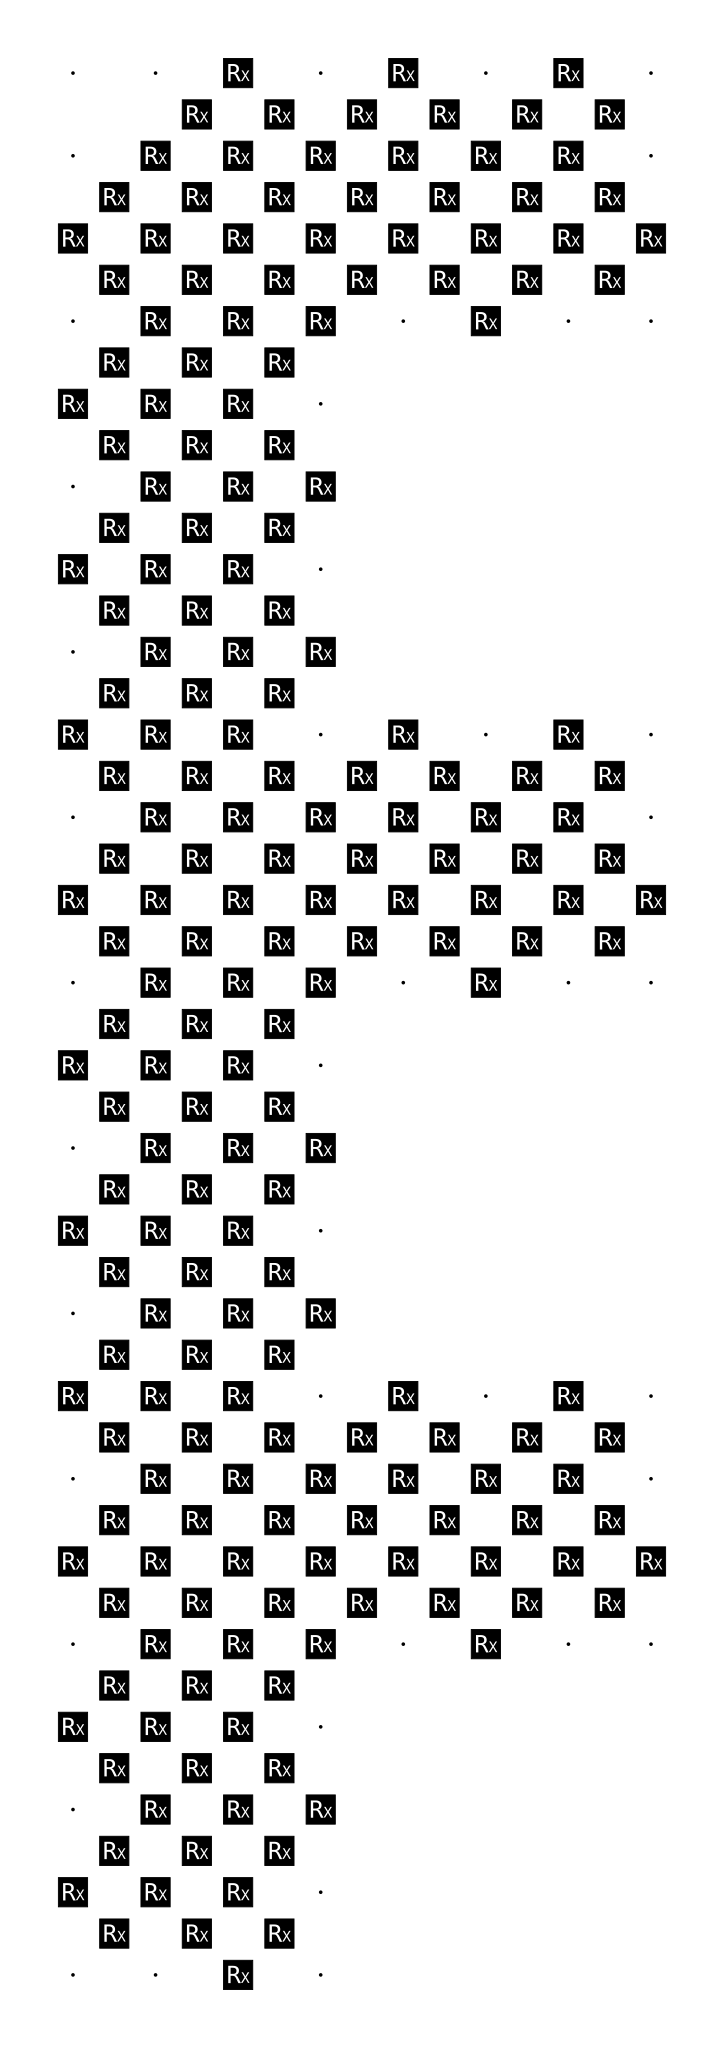


Tick 10/41:


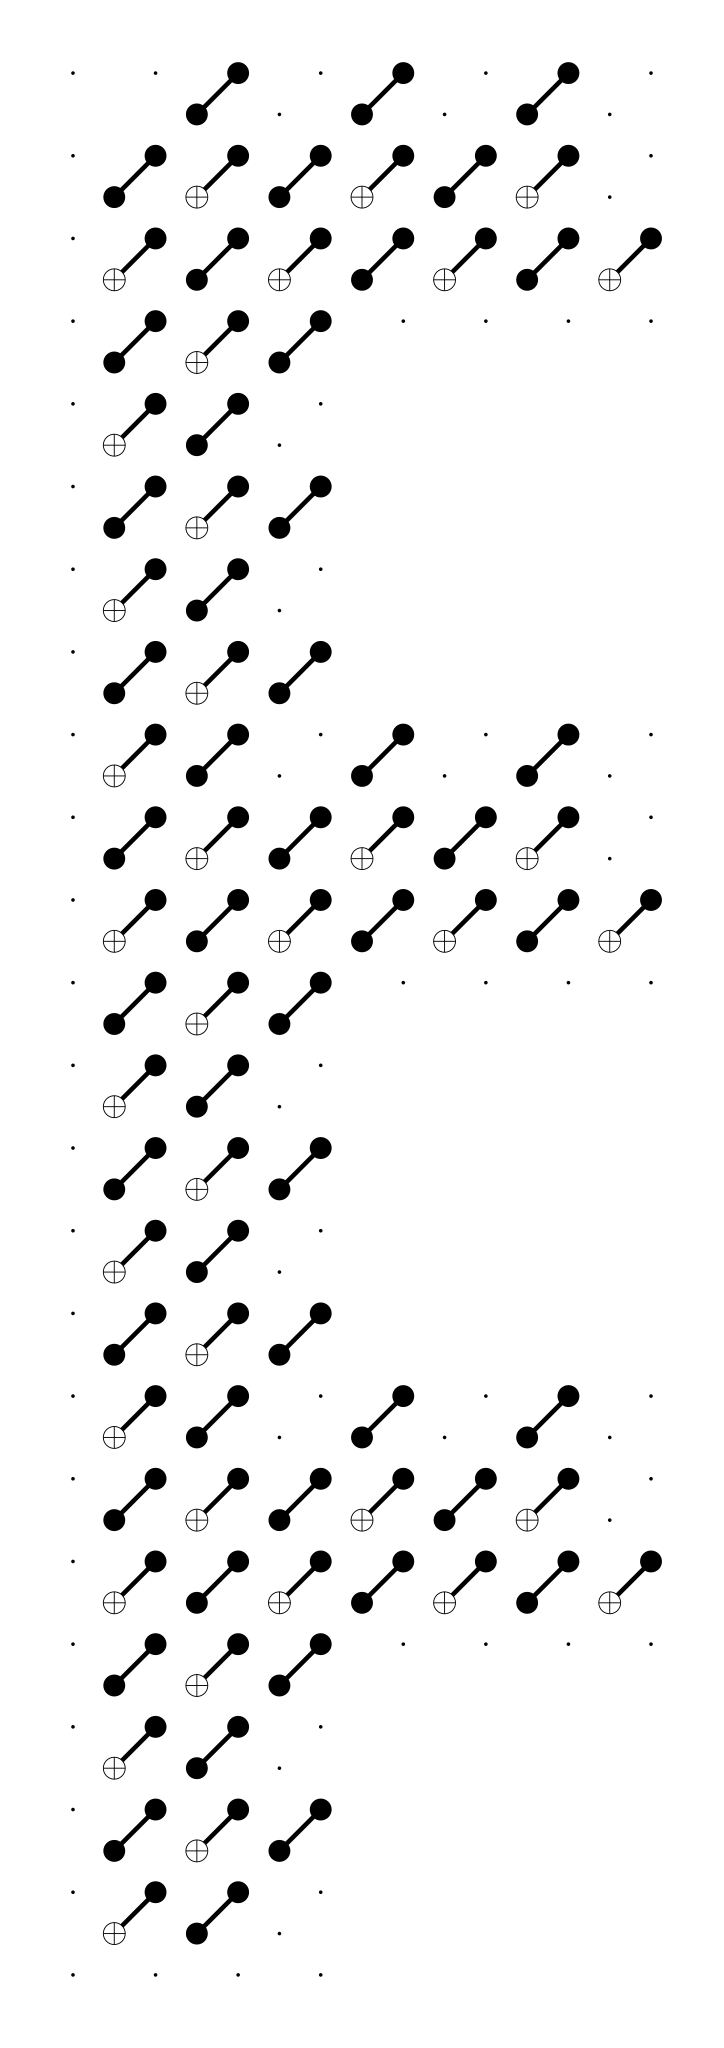


Tick 20/41:


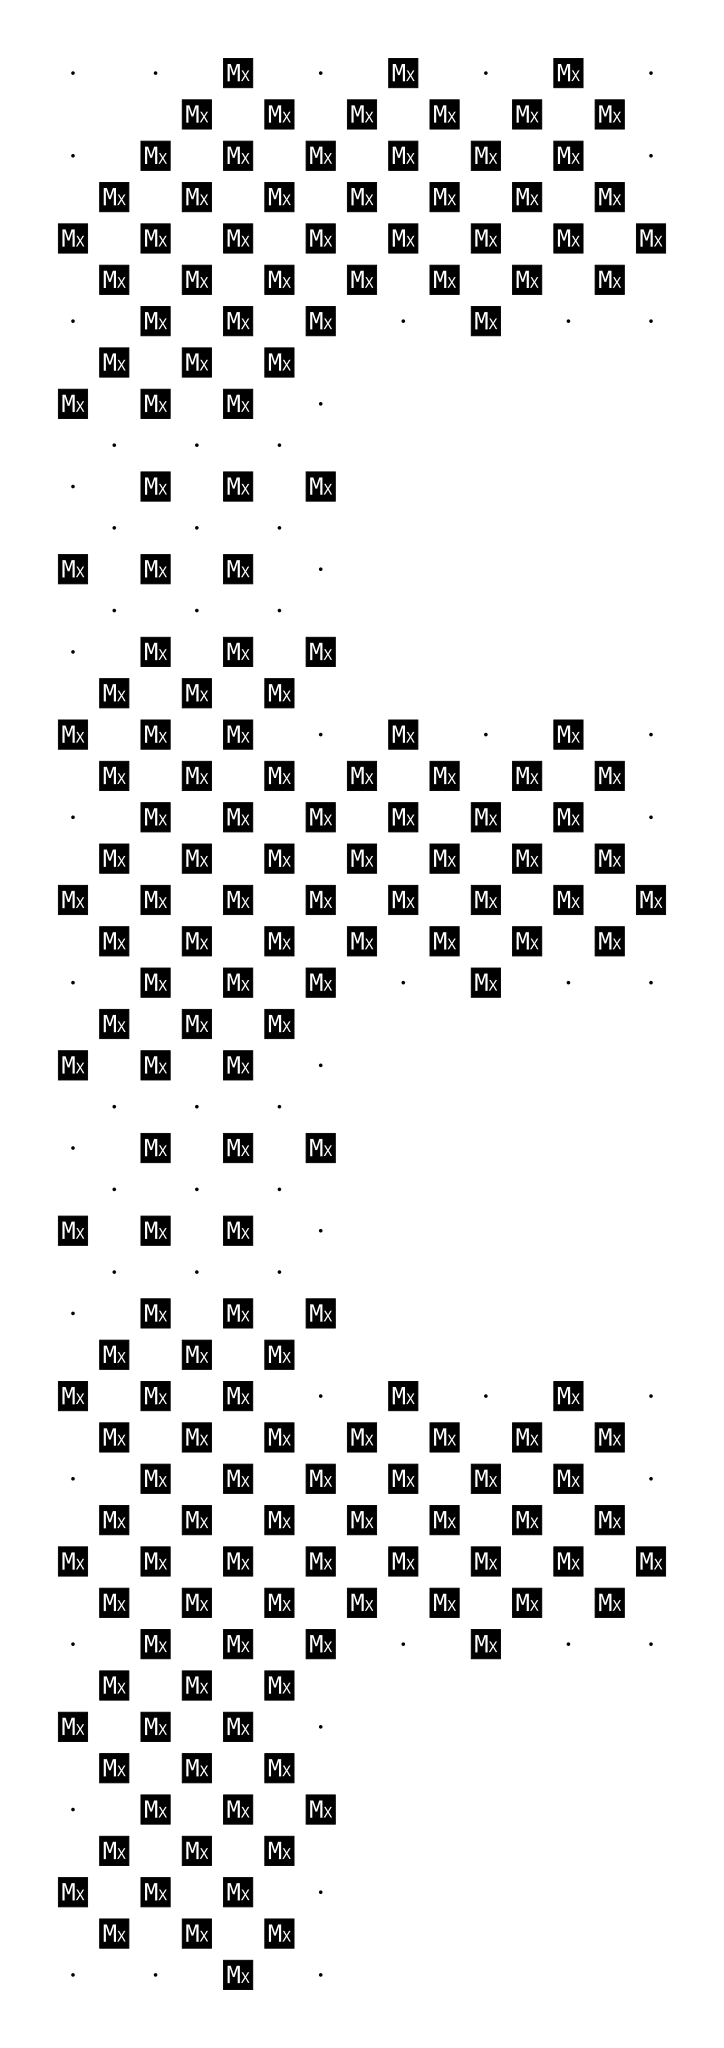


Tick 30/41:


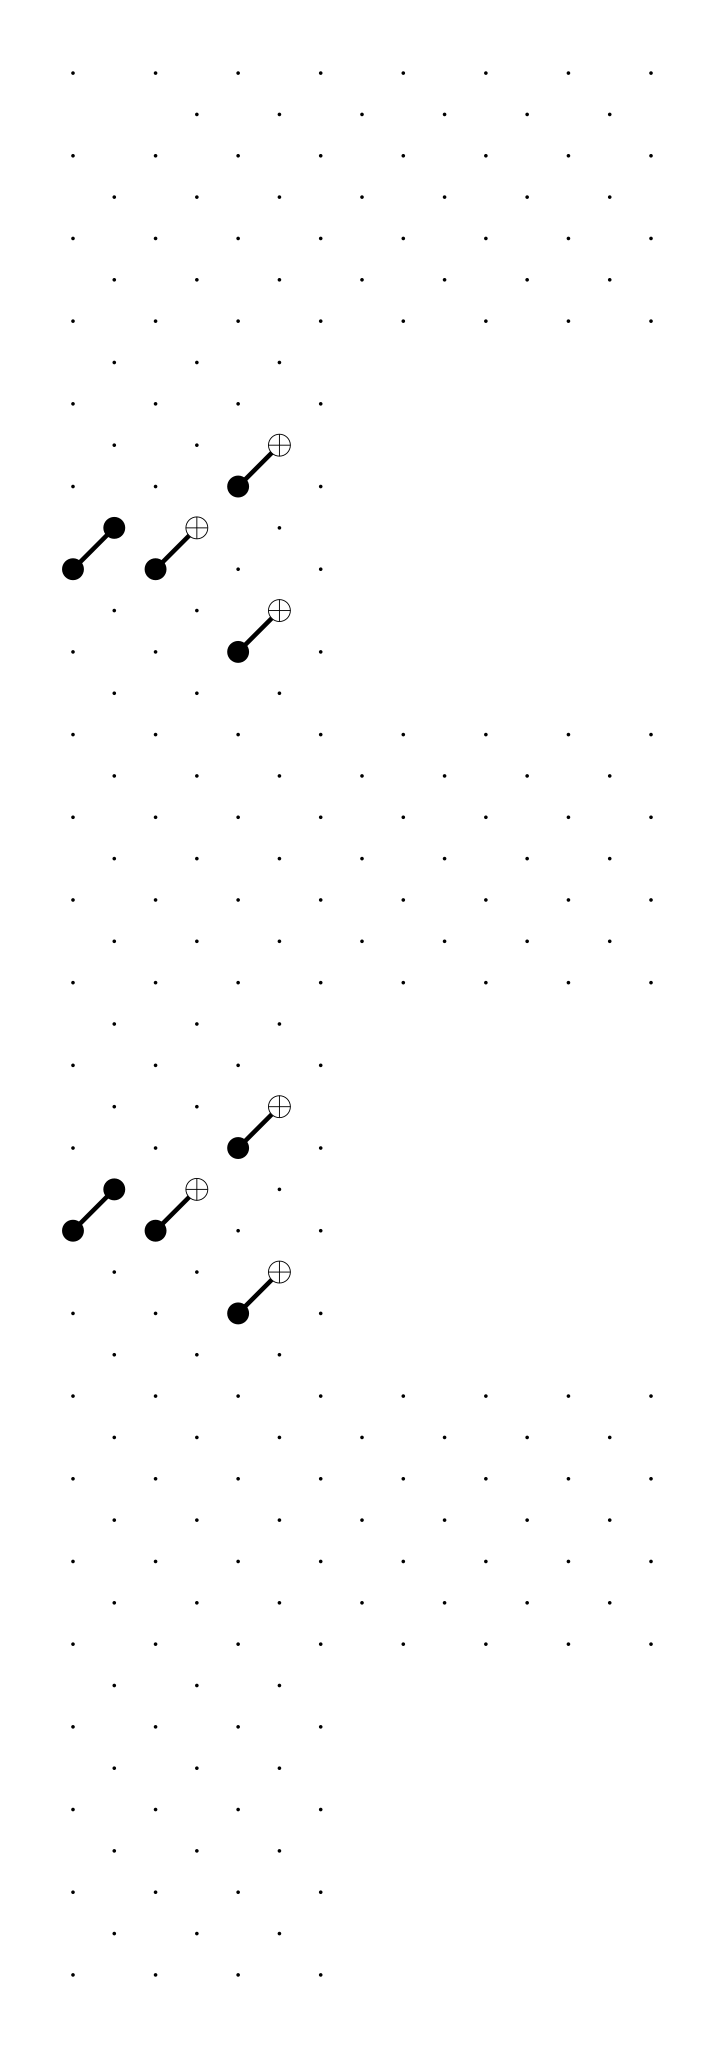


=== Detector Slice (tick 20) ===


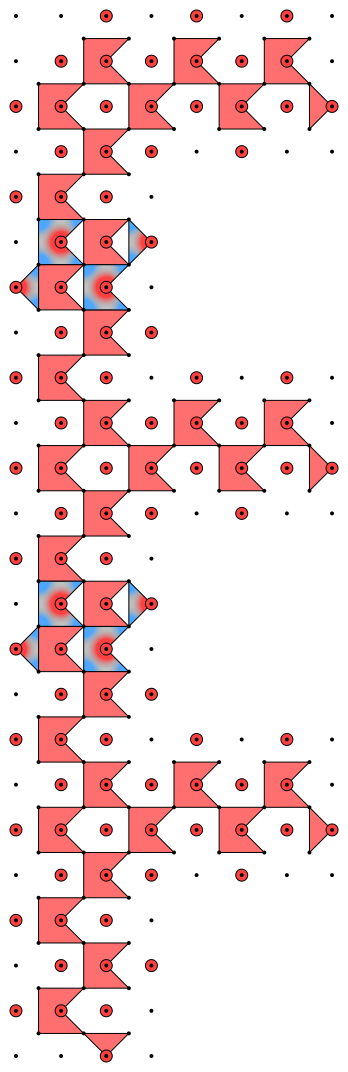

In [13]:
from IPython.display import display, SVG

# === Timeslice Diagrams: 2D surface code patches at individual time steps ===
circ_d3 = compiled.generate_stim_circuit(k=1)
n_ticks = circ_d3.num_ticks
print(f"=== Surface Code Patches (d=3, {circ_d3.num_qubits} qubits, {n_ticks} ticks) ===")

ticks = sorted(set([0, n_ticks // 4, n_ticks // 2, 3 * n_ticks // 4]))
for tick in ticks:
    print(f"\nTick {tick}/{n_ticks}:")
    display(SVG(data=str(circ_d3.diagram("timeslice-svg", tick=tick))))

# === Detector Slice: stabilizer structure at midpoint ===
print(f"\n=== Detector Slice (tick {n_ticks // 2}) ===")
display(SVG(data=str(circ_d3.diagram("detslice-svg", tick=n_ticks // 2))))

Crumble URL for d=3 (25097 chars):



Timeline: 248 qubits x 41 ticks


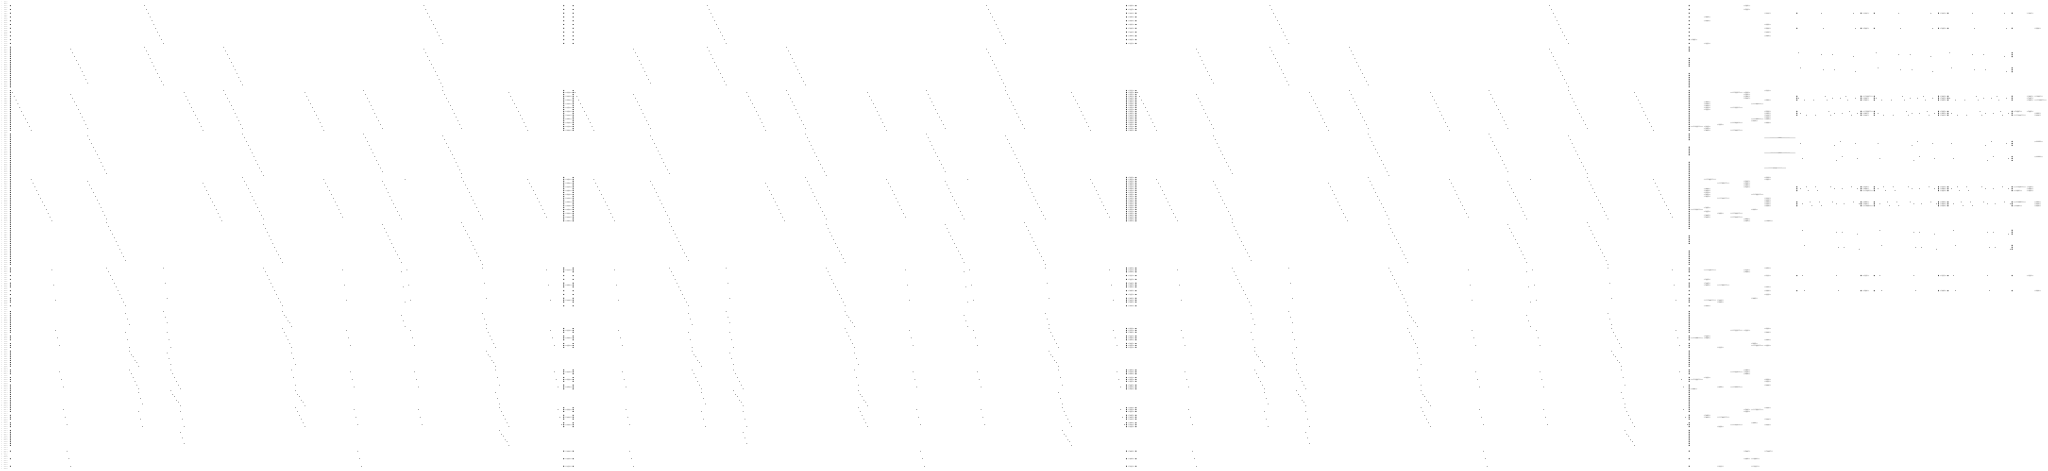

In [14]:
from IPython.display import HTML, SVG

# Crumble: interactive surface code viewer (open in browser)
crumble_url = compiled.generate_crumble_url(k=1)
print(f"Crumble URL for d=3 ({len(crumble_url)} chars):")
display(HTML(f'<a href="{crumble_url}" target="_blank">Open in Crumble (d=3)</a>'))

# Inline SVG: timeline of the stim circuit at d=3
circ_d3 = compiled.generate_stim_circuit(k=1)
print(f"\nTimeline: {circ_d3.num_qubits} qubits x {circ_d3.num_ticks} ticks")
display(SVG(data=str(circ_d3.diagram("timeline-svg"))))

## 7. Scaling: Arbitrary Clifford Circuits

Test the pipeline on diverse circuits: GHZ states, graph states (CZ),
mixed Clifford, and star topologies.

All circuits use the `to_rg()` optimization by default.

In [15]:
def make_zx_graph(circuit_fn):
    """Helper: build PyZX circuit, convert to graph, full_reduce."""
    c = circuit_fn()
    g = c.to_graph()
    zx.simplify.full_reduce(g)
    return g

# Define test circuits
test_circuits = {
    "GHZ-3": lambda: (lambda c: (c.add_gate('HAD', 2), c.add_gate('CNOT', 2, 1),
                       c.add_gate('CNOT', 1, 0), c)[-1])(zx.Circuit(3)),
    "GHZ-5": lambda: (lambda c: ([c.add_gate('HAD', 4)] +
                       [c.add_gate('CNOT', i+1, i) for i in range(3, -1, -1)],
                       c)[-1])(zx.Circuit(5)),
    "GHZ-10": lambda: (lambda c: ([c.add_gate('HAD', 9)] +
                        [c.add_gate('CNOT', i+1, i) for i in range(8, -1, -1)],
                        c)[-1])(zx.Circuit(10)),
    "GHZ-20": lambda: (lambda c: ([c.add_gate('HAD', 19)] +
                        [c.add_gate('CNOT', i+1, i) for i in range(18, -1, -1)],
                        c)[-1])(zx.Circuit(20)),
    "Graph-4 (CZ)": lambda: (lambda c: ([c.add_gate('HAD', i) for i in range(4)] +
                              [c.add_gate('CZ', i, i+1) for i in range(3)],
                              c)[-1])(zx.Circuit(4)),
    "Star-5 (CZ)": lambda: (lambda c: ([c.add_gate('HAD', i) for i in range(5)] +
                             [c.add_gate('CZ', 0, i) for i in range(1, 5)],
                             c)[-1])(zx.Circuit(5)),
    "Clifford-mix": lambda: (lambda c: (c.add_gate('HAD', 0), c.add_gate('CNOT', 0, 1),
                              c.add_gate('HAD', 1), c.add_gate('CNOT', 1, 2),
                              c.add_gate('HAD', 2), c)[-1])(zx.Circuit(3)),
    "3Q-mix": lambda: (lambda c: (c.add_gate('HAD', 2), c.add_gate('CNOT', 1, 2),
                        c.add_gate('CNOT', 0, 2), c.add_gate('HAD', 2),
                        c.add_gate('CNOT', 0, 1), c)[-1])(zx.Circuit(3)),
}

print(f"{'Circuit':>16}  {'ZX verts':>8}  {'Cubes':>5}  {'Phys Q (d=3)':>12}  {'Det':>6}  Att")
print("-" * 64)

for name, circuit_fn in test_circuits.items():
    g = make_zx_graph(circuit_fn)
    nv = len(list(g.vertices()))
    try:
        random.seed(42)
        bg, att = zx_to_block_graph(g, use_to_rg=True)
        filled = bg.fill_ports_for_minimal_simulation()
        compiled = compile_block_graph(filled[0].graph)
        circ = compiled.generate_stim_circuit(k=1)
        print(f"{name:>16}  {nv:>8}  {len(bg.cubes):>5}  {circ.num_qubits:>12}  "
              f"{circ.num_detectors:>6}  {att}")
    except Exception as e:
        print(f"{name:>16}  {nv:>8}  FAILED: {str(e)[:40]}")

         Circuit  ZX verts  Cubes  Phys Q (d=3)     Det  Att
----------------------------------------------------------------
           GHZ-3        10     11           248     326  1
           GHZ-5        18     19           305     554  1
          GHZ-10        38     39           611    1146  1
          GHZ-20        78     79          1283    2346  1
    Graph-4 (CZ)        12     16           354     466  1
     Star-5 (CZ)        15     21           276     614  1
    Clifford-mix         9     12           192     347  1
          3Q-mix        10     16           305     472  1


## 8. `to_rg()` Optimization: Before vs After Comparison

`full_reduce()` produces graph-like form (all Z-spiders, all Hadamard edges). Our
`eliminate_hadamard_edges()` inserts an X(0) identity spider for every Hadamard edge — ~70% overhead.

PyZX's `to_rg()` uses a max-cut heuristic to recolor spiders (Z↔X), converting most
Hadamard edges to simple edges. Only 1-4 Hadamard edges typically remain, dramatically
reducing the identity spiders needed.

| Step | GHZ-3 Had edges | GHZ-20 Had edges |
|------|-----------------|------------------|
| After `full_reduce()` | 7 | 58 |
| After `to_rg()` | 1 | 1 |
| Identity spiders needed | 1 (was 7) | 1 (was 58) |

In [16]:
# Compare with and without to_rg() across all test circuits
print(f"{'Circuit':>12} | {'ZX':>3} | {'Had':>3} {'->':>2} {'rg':>2} | "
      f"{'Old cubes':>9} | {'New cubes':>9} | {'Cube red':>8} | "
      f"{'Old Q(d3)':>9} | {'New Q(d3)':>9} | {'Q red':>6} | Noiseless")
print("-" * 105)

comparison_results = {}
for name, circuit_fn in test_circuits.items():
    g = make_zx_graph(circuit_fn)
    nv = len(list(g.vertices()))

    # Count Hadamard edges before/after to_rg
    had_orig = sum(1 for u, v in g.edges()
                   if g.edge_type(g.edge(u, v)) == zx.EdgeType.HADAMARD)
    g_rg = g.copy()
    to_rg(g_rg)
    had_rg = sum(1 for u, v in g_rg.edges()
                 if g_rg.edge_type(g_rg.edge(u, v)) == zx.EdgeType.HADAMARD)

    try:
        # Without to_rg
        random.seed(42)
        bg_old, _ = zx_to_block_graph(g, use_to_rg=False)
        f_old = bg_old.fill_ports_for_minimal_simulation()
        c_old = compile_block_graph(f_old[0].graph)
        circ_old = c_old.generate_stim_circuit(k=1)

        # With to_rg
        random.seed(42)
        bg_new, _ = zx_to_block_graph(g, use_to_rg=True)
        f_new = bg_new.fill_ports_for_minimal_simulation()
        c_new = compile_block_graph(f_new[0].graph)
        circ_new = c_new.generate_stim_circuit(k=1)

        # Noiseless check
        _, obs_new = circ_new.compile_detector_sampler().sample(
            shots=10000, separate_observables=True)
        noiseless = "PASS" if obs_new.any(axis=1).mean() == 0.0 else "FAIL"

        old_c, new_c = len(bg_old.cubes), len(bg_new.cubes)
        old_q, new_q = circ_old.num_qubits, circ_new.num_qubits
        cube_red = f"{100*(1 - new_c/old_c):.0f}%"
        q_red = f"{100*(1 - new_q/old_q):.0f}%"

        comparison_results[name] = {
            "old_cubes": old_c, "new_cubes": new_c,
            "old_qubits": old_q, "new_qubits": new_q,
            "compiled_new": c_new
        }

        print(f"{name:>12} | {nv:>3} | {had_orig:>3} -> {had_rg:>2} | "
              f"{old_c:>9} | {new_c:>9} | {cube_red:>8} | "
              f"{old_q:>9} | {new_q:>9} | {q_red:>6} | {noiseless}")
    except Exception as e:
        print(f"{name:>12} | {nv:>3} | {had_orig:>3} -> {had_rg:>2} | FAILED: {str(e)[:40]}")

     Circuit |  ZX | Had -> rg | Old cubes | New cubes | Cube red | Old Q(d3) | New Q(d3) |  Q red | Noiseless
---------------------------------------------------------------------------------------------------------
       GHZ-3 |  10 |   7 ->  1 |        17 |        11 |      35% |       305 |       248 |    19% | PASS
       GHZ-5 |  18 |  13 ->  1 |        31 |        19 |      39% |       668 |       305 |    54% | PASS
      GHZ-10 |  38 |  28 ->  1 |        66 |        39 |      41% |      1278 |       611 |    52% | PASS
      GHZ-20 |  78 |  58 ->  1 |       136 |        79 |      42% |      2830 |      1283 |    55% | PASS
Graph-4 (CZ) |  12 |   7 ->  4 |        19 |        16 |      16% |       330 |       354 |    -7% | PASS
 Star-5 (CZ) |  15 |   9 ->  5 |        25 |        21 |      16% |       413 |       276 |    33% | PASS
Clifford-mix |   9 |   5 ->  3 |        14 |        12 |      14% |       246 |       192 |    22% | PASS
      3Q-mix |  10 |   5 ->  4 |        2

### Decoded Error Rate Comparison

Compare decoded logical error rates at d=3,5,7 for GHZ-3 with and without `to_rg()`.
Fewer cubes means fewer error sources — we expect equal or better error rates.

In [17]:
# Decoded error rates: with vs without to_rg() for GHZ-3
g_ghz3 = make_zx_graph(test_circuits["GHZ-3"])
noise = NoiseModel.uniform_depolarizing(0.001)
shots = 100_000

for label, use_rg in [("Without to_rg()", False), ("With to_rg()", True)]:
    random.seed(42)
    bg, _ = zx_to_block_graph(g_ghz3, use_to_rg=use_rg)
    filled = bg.fill_ports_for_minimal_simulation()
    comp = compile_block_graph(filled[0].graph)
    print(f"=== GHZ-3 {label} ({len(bg.cubes)} cubes) ===")
    for k in [1, 2, 3]:
        d = 2 * k + 1
        circ = comp.generate_stim_circuit(k=k)
        circ_noisy = noise.noisy_circuit(circ)
        dem = circ_noisy.detector_error_model(decompose_errors=True)
        matcher = pymatching.Matching.from_detector_error_model(dem)
        sampler = circ_noisy.compile_detector_sampler()
        det_events, obs_actual = sampler.sample(shots=shots, separate_observables=True)
        obs_predicted = matcher.decode_batch(det_events)
        num_errors = np.any(obs_predicted != obs_actual, axis=1).sum()
        err = num_errors / shots
        print(f"  d={d}: {err:.6f} ({num_errors}/{shots}, {circ.num_qubits} qubits)")
    print()

=== GHZ-3 Without to_rg() (17 cubes) ===
  d=3: 0.048860 (4886/100000, 305 qubits)
  d=5: 0.013830 (1383/100000, 723 qubits)
  d=7: 0.002670 (267/100000, 1317 qubits)

=== GHZ-3 With to_rg() (11 cubes) ===
  d=3: 0.037240 (3724/100000, 248 qubits)
  d=5: 0.011430 (1143/100000, 588 qubits)
  d=7: 0.002320 (232/100000, 1072 qubits)

